# 07. Taylor Series and Convergence Rates

**Part 1: Foundations of Numerical Computing**

## Learning objectives

By the end of this lesson you will be able to:

1. State **Taylor's theorem with remainder** and use the remainder term to bound a truncation
   error.
2. Use the **intermediate value**, **mean value** and **Rolle** theorems, which are the
   engines behind almost every error proof in this course.
3. Read and write **big-O** and **little-o** notation without ambiguity.
4. Define **order of convergence** and **asymptotic error constant**.
5. **Measure** an observed order from numerical data, and know when the measurement is
   meaningless.
6. Tell the two kinds of convergence claim apart: **iterative** (error against step number)
   and **discretisation** (error against step size).

## Prerequisites

Lessons 01 to 06. First year calculus.

---

## 1. Why this lesson exists

Almost every method in this course is justified by the same three-step argument:

```text
1. Expand the exact quantity in a Taylor series about a convenient point.
2. Keep a few terms. Those become the method.
3. The terms you dropped are the truncation error. Bound them.
```

Step 3 is what turns a plausible formula into a theorem with an error estimate attached. And
every claim of the form "this method is second order" is a claim about the size of the dropped
terms, which we will then check numerically rather than take on trust.

## 2. The calculus we keep using

Four theorems. Each is a tool we will reach for repeatedly.

> **Theorem 7.1 (Intermediate Value Theorem).** If $f$ is continuous on $[a,b]$ and $y$ lies
> between $f(a)$ and $f(b)$, then $f(c) = y$ for some $c \in (a,b)$.

This is the entire justification for **bisection** (lesson 09). A sign change guarantees a
root, and that guarantee is why bisection can never fail.

> **Theorem 7.2 (Rolle's Theorem).** If $f$ is continuous on $[a,b]$, differentiable on
> $(a,b)$, and $f(a) = f(b)$, then $f'(c) = 0$ for some $c \in (a,b)$.

This is the engine behind the **interpolation error formula** (lesson 45). An interpolant
agrees with $f$ at $n+1$ points, so the difference has $n+1$ zeros, so repeated Rolle produces
a point where the $n$-th derivative of the difference vanishes.

> **Theorem 7.3 (Mean Value Theorem).** If $f$ is continuous on $[a,b]$ and differentiable on
> $(a,b)$, then
> $$f(b) - f(a) = f'(c)(b - a) \quad\text{for some } c \in (a,b).$$

This converts differences into derivatives, which is how every finite difference formula gets
its error term.

> **Theorem 7.4 (Taylor's theorem with Lagrange remainder).** If $f$ has $n+1$ continuous
> derivatives on an interval containing $a$ and $x$, then
>
> $$f(x) = \underbrace{\sum_{k=0}^{n} \frac{f^{(k)}(a)}{k!}(x-a)^k}_{\text{the polynomial you keep}}
> \;+\; \underbrace{\frac{f^{(n+1)}(\xi)}{(n+1)!}(x-a)^{n+1}}_{\text{the remainder}}$$
>
> for some $\xi$ strictly between $a$ and $x$.

The remainder term is the important half. It is **exact**, not an approximation, and it tells
you three things at once:

- The error is proportional to $(x-a)^{n+1}$, so halving the distance divides the error by
  $2^{n+1}$. That is the **order**.
- The error is proportional to the $(n+1)$-th derivative, so functions with large high
  derivatives are approximated badly. That is why the Runge phenomenon happens (lesson 45).
- $\xi$ is unknown, so you bound $|f^{(n+1)}|$ over the interval to get a usable estimate.

### Checking Taylor's theorem numerically

Take $f(x) = e^x$ about $a = 0$. Then $f^{(k)}(0) = 1$ for all $k$, so the remainder after $n$
terms is $e^{\xi} x^{n+1} / (n+1)!$ with $\xi$ between 0 and $x$.

In [1]:
# Standard setup, the same in every lesson of this course.
import sys, pathlib

_root = pathlib.Path.cwd()
while not (_root / "src" / "nalib").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

SEED = 42                                  # fixed so your numbers match the text
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=6, linewidth=100, suppress=False)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

In [2]:
from math import factorial

def taylor_exp(x, n):
    """Sum the terms x^k / k! for k = 0..n.

    Each term is built from the previous one by multiplying by x/k, so no factorial or
    power is ever formed directly. That keeps the cost at one multiply and one divide per
    term, and avoids the overflow you would hit computing 170! on its own.
    """
    total = 0.0
    term = 1.0                      # this is x^0 / 0!
    for k in range(n + 1):
        if k > 0:
            term = term * x / k     # x^k/k! from x^(k-1)/(k-1)!
        total += term
    return total


x = 0.5
print(f"Taylor series for exp({x}) about 0, and the Lagrange remainder bound\n")
print(f"{'n':>3} {'partial sum':>20} {'actual error':>15} {'bound':>15} {'bound holds':>12}")
print("-" * 70)
exact = np.exp(x)
for n in range(0, 9):
    approx = taylor_exp(x, n)
    actual = abs(exact - approx)
    # |remainder| <= max|f^(n+1)| on [0,x] times x^(n+1)/(n+1)!  = e^x x^(n+1)/(n+1)!
    bound = np.exp(x) * x**(n + 1) / factorial(n + 1)
    ok = actual <= bound * (1 + 1e-12)
    print(f"{n:>3} {approx:>20.15f} {actual:>15.3e} {bound:>15.3e} {str(ok):>12}")
    assert ok, f"Lagrange remainder bound violated at n={n}"

print(f"\nexact value: {exact:.15f}")
print("the bound held at every order, and it is tight to within a small factor.")

Taylor series for exp(0.5) about 0, and the Lagrange remainder bound

  n          partial sum    actual error           bound  bound holds
----------------------------------------------------------------------
  0    1.000000000000000       6.487e-01       8.244e-01         True
  1    1.500000000000000       1.487e-01       2.061e-01         True
  2    1.625000000000000       2.372e-02       3.435e-02         True
  3    1.645833333333333       2.888e-03       4.294e-03         True
  4    1.648437500000000       2.838e-04       4.294e-04         True
  5    1.648697916666667       2.335e-05       3.578e-05         True
  6    1.648719618055555       1.653e-06       2.556e-06         True
  7    1.648721168154762       1.025e-07       1.597e-07         True
  8    1.648721265035962       5.664e-09       8.874e-09         True

exact value: 1.648721270700128
the bound held at every order, and it is tight to within a small factor.


## 3. Order notation

Two symbols, used constantly and often sloppily. Here is the precise meaning.

> **Definition 7.5.** As $h \to 0$,
>
> - $g(h) = O(h^p)$ means there are constants $C$ and $h_0$ with $|g(h)| \le C|h|^p$ for all
>   $|h| < h_0$. Read as **"grows no faster than"**.
> - $g(h) = o(h^p)$ means $g(h)/h^p \to 0$. Read as **"grows strictly slower than"**.

The same notation is used for $n \to \infty$, with the inequality the other way round: an
algorithm is $O(n^3)$ when its cost is at most $Cn^3$ for large $n$.

**A warning about constants.** $O$ hides the constant $C$, and constants matter in practice.
An $O(n^2)$ method with a small constant beats an $O(n \log n)$ method with a huge one for
every $n$ you will ever run. Lesson 08 measures the constants rather than hiding them.

The two common mistakes:

1. Writing $O(h^2)$ when you mean "the error is roughly $Ch^2$". $O$ is an upper bound. A
   method whose error is genuinely $Ch^2$ with $C \ne 0$ has error $O(h^2)$ **and** is not
   $o(h^2)$.
2. Forgetting which limit is meant. $O(h^2)$ as $h \to 0$ is *good*. $O(n^2)$ as
   $n \to \infty$ is *bad*.

## 4. Order of convergence

Now the definition that gets used for every iterative method in this course.

> **Definition 7.6 (Order of convergence).** Let $e_k = |x_k - x_\star|$ be the error at step
> $k$ of a sequence converging to $x_\star$. The sequence converges with **order** $p$ and
> **asymptotic error constant** $C$ if
>
> $$\lim_{k \to \infty} \frac{e_{k+1}}{e_k^{\,p}} = C, \qquad 0 < C < \infty.$$

The standard names:

| $p$ | Name | Behaviour of the error | Example |
|---|---|---|---|
| 1, with $C < 1$ | **linear** | multiplied by $C$ each step, so digits arrive at a steady rate | bisection ($C = 1/2$), fixed point iteration |
| 1, with $C = 1$ | **sublinear** | slower than any geometric rate | some series |
| between 1 and 2 | **superlinear** | faster than linear, slower than quadratic | secant method ($p \approx 1.618$) |
| 2 | **quadratic** | correct digits roughly **double** each step | Newton's method |
| 3 | **cubic** | digits roughly triple | Rayleigh quotient iteration, Chebyshev's method |

The practical difference is dramatic. Linear convergence with $C = 1/2$ gains about **0.3
decimal digits** per step, so reaching 16 digits takes about 53 steps. Quadratic convergence
reaching 16 digits from 1 correct digit takes **4 steps**.

## 5. Measuring the order

Take logs of $e_{k+1} \approx C e_k^p$ for two consecutive steps and divide, and $C$ cancels:

$$p_k \;=\; \frac{\log\!\left(e_{k+1} / e_k\right)}{\log\!\left(e_k / e_{k-1}\right)}.$$

This needs three consecutive errors and gives one estimate. That is what
`nalib.convergence.observed_order` computes.

**Four warnings, and they all matter.**

1. **Early steps lie.** The definition is a limit. Before the iteration settles into its
   asymptotic behaviour, the estimates wander.
2. **Late steps lie too.** Once the error reaches roundoff level, $e_k$ is noise and the
   estimates are meaningless. `nalib` truncates the sequence at the first zero or non-finite
   error for exactly this reason.
3. **There is usually only a narrow window** in the middle where the measurement is valid. On
   a quadratically convergent method that window can be two or three steps wide, because the
   method goes from useless to exact so quickly.
4. **This formula does not work for linear methods.** That deserves its own explanation.

### Why linear methods need a different measurement

For a linear method, $p = 1$ and $e_{k+1} \approx C e_k$. Substituting into the order formula
gives $p_k = \log(C)/\log(C) = 1$, which is fine in theory. In practice the interesting number
is $C$, not $p$, and worse, the formula is numerically fragile here: if two consecutive errors
happen to be close, the denominator $\log(e_k/e_{k-1})$ is near zero and the estimate explodes.

Bisection makes the point sharply. Its **bracket** halves exactly every step, but the
**distance from the midpoint to the root** does not. A midpoint can land almost on the root by
luck, and then the next one is far worse.

In [3]:
from nalib import convergence as cv

TARGET = np.sqrt(2.0)


def bisection_run(a=1.0, b=2.0, steps=50):
    """Returns the actual midpoint errors and the guaranteed bracket half-widths."""
    f = lambda t: t * t - 2.0
    errs, bounds = [], []
    for _ in range(steps):
        m = 0.5 * (a + b)
        errs.append(abs(m - TARGET))
        bounds.append(0.5 * (b - a))
        if f(a) * f(m) <= 0:
            b = m
        else:
            a = m
    return np.array(errs), np.array(bounds)


bis_err, bis_bound = bisection_run()

print("bisection: consecutive error ratios e_k / e_(k-1)")
print(np.round(bis_err[1:10] / bis_err[:9], 4))
print("\nbisection: consecutive BOUND ratios (bracket half-width)")
print(np.round(bis_bound[1:10] / bis_bound[:9], 6))

print(f"\nthe error ratios range from {(bis_err[1:20]/bis_err[:19]).min():.3f} "
      f"to {(bis_err[1:20]/bis_err[:19]).max():.1f}.")
print("the bracket ratios are exactly 0.5 every single time.")
print("\nso for a linear method, fit the DECAY across the whole run instead of")
print("trusting any single ratio. that is what nalib.convergence.linear_rate does.")

bisection: consecutive error ratios e_k / e_(k-1)
[1.91420e+00 2.38800e-01 5.93800e-01 3.42000e-01 9.62100e-01 1.97000e-02 2.48585e+01 4.79900e-01
 4.58100e-01]

bisection: consecutive BOUND ratios (bracket half-width)
[0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]

the error ratios range from 0.020 to 24.9.
the bracket ratios are exactly 0.5 every single time.

so for a linear method, fit the DECAY across the whole run instead of
trusting any single ratio. that is what nalib.convergence.linear_rate does.


So the honest procedure is:

| Method type | What to measure | How |
|---|---|---|
| **Linear** ($p = 1$) | the rate constant $C$ | fit $\log e_k$ against $k$, take $e^{\text{slope}}$ |
| **Superlinear** ($p > 1$) | the order $p$ | the three-point formula above |

Let us do both on the same problem: finding $\sqrt{2}$ as a root of $f(x) = x^2 - 2$.

In [4]:
def fixed_point_run(x=1.0, steps=60):
    """g(x) = 0.7x + 0.6/x has a fixed point at sqrt(2).

    g'(x) = 0.7 - 0.6/x^2, so g'(sqrt(2)) = 0.7 - 0.3 = 0.4.
    Theory says linear convergence with C = |g'(r)| = 0.4.
    """
    errs = []
    for _ in range(steps):
        x = 0.7 * x + 0.6 / x
        errs.append(abs(x - TARGET))
    return np.array(errs)


def secant_run(x0=1.0, x1=2.0, steps=12):
    """Superlinear, p = the golden ratio."""
    f = lambda t: t * t - 2.0
    errs = []
    for _ in range(steps):
        f0, f1 = f(x0), f(x1)
        if f1 == f0:
            break
        x0, x1 = x1, x1 - f1 * (x1 - x0) / (f1 - f0)
        errs.append(abs(x1 - TARGET))
    return np.array(errs)


def newton_run(x=1.0, steps=10):
    """Quadratic, p = 2."""
    errs = []
    for _ in range(steps):
        x = x - (x * x - 2.0) / (2.0 * x)
        errs.append(abs(x - TARGET))
    return np.array(errs)


fix_err = fixed_point_run()
sec_err = secant_run()
new_err = newton_run()

print("LINEAR METHODS: measure the rate constant C")
print(f"{'method':>22} {'theory C':>11} {'measured C':>12} {'steps to 1e-12':>16}")
print("-" * 64)
linear_cases = [
    ("bisection (bracket)", bis_bound, 0.5),
    ("damped fixed point",  fix_err,   0.4),
]
for name, errs, theory_C in linear_cases:
    measured = cv.linear_rate(errs)
    reached = cv.steps_to_tolerance(errs, 1e-12)
    print(f"{name:>22} {theory_C:>11.4f} {measured:>12.4f} "
          f"{reached if reached >= 0 else 'never':>16}")
    assert abs(measured - theory_C) < 0.02, f"{name}: C off"

print("\nSUPERLINEAR METHODS: measure the order p")
print(f"{'method':>22} {'theory p':>11} {'measured p':>12} {'steps to 1e-12':>16}")
print("-" * 64)
superlinear_cases = [
    ("secant", sec_err, (1 + np.sqrt(5)) / 2),
    ("Newton", new_err, 2.0),
]
for name, errs, theory_p in superlinear_cases:
    orders = cv.observed_order(errs)
    measured = float(orders[-1]) if orders.size else float("nan")
    reached = cv.steps_to_tolerance(errs, 1e-12)
    print(f"{name:>22} {theory_p:>11.4f} {measured:>12.4f} "
          f"{reached if reached >= 0 else 'never':>16}")
    assert abs(measured - theory_p) < 0.1, f"{name}: p off"

print("\nevery measured value matched its theory.")
print(f"\nnote the last column. bisection needs "
      f"{cv.steps_to_tolerance(bis_bound, 1e-12)} steps to guarantee 1e-12.")
print(f"Newton needs {cv.steps_to_tolerance(new_err, 1e-12)}.")

LINEAR METHODS: measure the rate constant C
                method    theory C   measured C   steps to 1e-12
----------------------------------------------------------------
   bisection (bracket)      0.5000       0.5000               39
    damped fixed point      0.4000       0.3996               28

SUPERLINEAR METHODS: measure the order p
                method    theory p   measured p   steps to 1e-12
----------------------------------------------------------------
                secant      1.6180       1.6075                5
                Newton      2.0000       1.9998                4

every measured value matched its theory.

note the last column. bisection needs 39 steps to guarantee 1e-12.
Newton needs 4.


### The convergence table for Newton

The clearest way to see quadratic convergence is a table. Watch the exponent in the error
column roughly double each row.

In [5]:
print(cv.convergence_table(newton_run(x=1.0, steps=8), exact_order=2))
print()
print("look at the exponents in the error column: -2, -3, -6, -12.")
print("each one is roughly double the previous. that IS quadratic convergence.")

  k        |e_k|      |e_k|/|e_(k-1)|   observed order   (theory: 2)
--------------------------------------------------------------------
  0    8.578644e-02                                
  1    2.453104e-03        0.028595                
  2    2.123901e-06        0.000866          1.9839
  3    1.594724e-12        0.000001          1.9998
  4    0.000000e+00        0.000000                
  5    2.220446e-16                                
  6    0.000000e+00        0.000000                
  7    2.220446e-16                                

look at the exponents in the error column: -2, -3, -6, -12.
each one is roughly double the previous. that IS quadratic convergence.


### And the picture

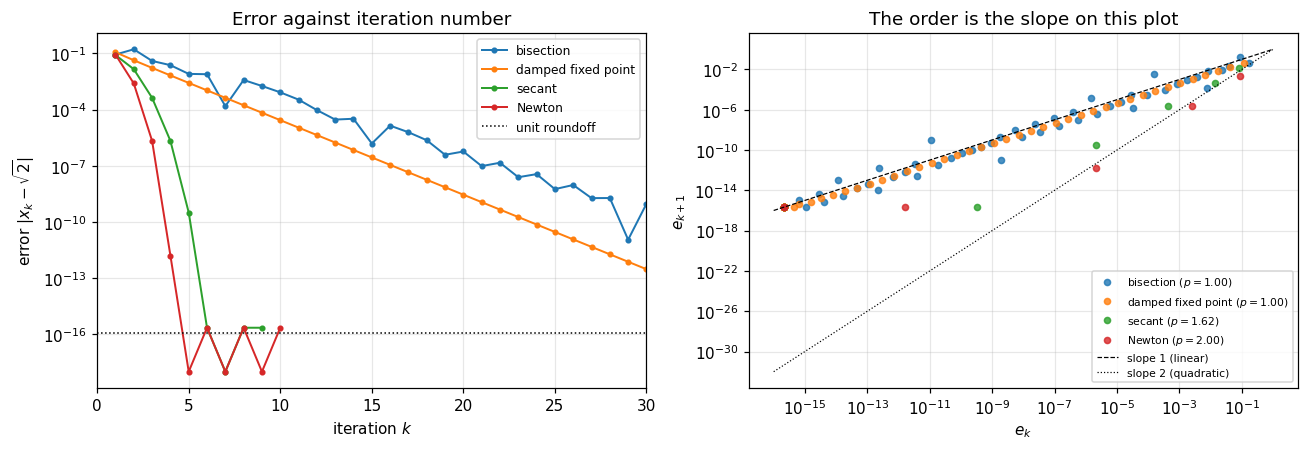

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))

all_runs = [
    ("bisection",          bis_err, 1.0),
    ("damped fixed point", fix_err, 1.0),
    ("secant",             sec_err, (1 + np.sqrt(5)) / 2),
    ("Newton",             new_err, 2.0),
]

for name, errs, theory in all_runs:
    e = np.maximum(errs, 1e-18)
    ax1.semilogy(np.arange(1, len(e) + 1), e, "o-", ms=3, lw=1.3, label=name)

ax1.axhline(np.finfo(float).eps / 2, color="k", ls=":", lw=1, label="unit roundoff")
ax1.set_xlim(0, 30)
ax1.set_xlabel("iteration $k$")
ax1.set_ylabel("error $|x_k - \\sqrt{2}|$")
ax1.set_title("Error against iteration number")
ax1.legend(fontsize=8)

# The order-of-convergence signature: plot e_{k+1} against e_k on log-log axes.
for name, errs, theory in all_runs:
    e = errs[errs > 1e-16]
    if e.size < 3:
        continue
    ax2.loglog(e[:-1], e[1:], "o", ms=4, alpha=0.8,
               label=f"{name} ($p={theory:.2f}$)")

ref = np.logspace(-16, 0, 10)
ax2.loglog(ref, ref, "k--", lw=0.8, label="slope 1 (linear)")
ax2.loglog(ref, ref**2, "k:", lw=0.8, label="slope 2 (quadratic)")
ax2.set_xlabel("$e_k$")
ax2.set_ylabel("$e_{k+1}$")
ax2.set_title("The order is the slope on this plot")
ax2.legend(fontsize=7)

fig.tight_layout()
plt.show()

**What to take from this.** The left panel shows what you feel when you run the methods:
bisection grinds down a straight line, Newton falls off a cliff. The right panel is the one
that *measures* the order. Plotting $e_{k+1}$ against $e_k$ on log-log axes turns
$e_{k+1} = Ce_k^p$ into a straight line of slope $p$. Bisection and the damped iteration sit
parallel to the slope-1 reference, Newton sits parallel to slope 2, and the secant method lies
between them.

## 6. The other kind of convergence

Iterative methods converge as the **step number** grows. Discretisation methods converge as the
**step size** shrinks. Both are called convergence and they are measured differently, so keep
them apart.

> **Definition 7.7 (Order of accuracy).** A discretisation has order of accuracy $p$ if its
> error satisfies $E(h) = O(h^p)$ as $h \to 0$.

Here $p$ is measured by a **refinement study**: halve $h$ and see how much the error falls.
If the error drops by $2^p$, the order is $p$.

$$p \;\approx\; \log_2 \frac{E(h)}{E(h/2)}.$$

In [7]:
from nalib import convergence as cv

def fd_error(h, order):
    """Error of a finite difference approximation to the derivative of exp at 1."""
    x = 1.0
    if order == 1:                       # forward difference, O(h)
        approx = (np.exp(x + h) - np.exp(x)) / h
    else:                                # central difference, O(h^2)
        approx = (np.exp(x + h) - np.exp(x - h)) / (2 * h)
    return abs(approx - np.exp(x))


# Stay well above the roundoff floor found in lesson 04, so we measure truncation only.
hs = np.array([2.0**-k for k in range(2, 14)])

for order, name in [(1, "forward difference"), (2, "central difference")]:
    errs = np.array([fd_error(h, order) for h in hs])
    measured = cv.refinement_order(hs, errs)
    halving = np.log2(errs[:-1] / errs[1:])
    print(f"{name:>20}: fitted order {measured:.4f}, "
          f"theory {order}, per-halving estimates "
          f"{np.round(halving[-4:], 3)}")
    assert abs(measured - order) < 0.05, f"{name} order mismatch"

print("\nboth match their theoretical order to two decimal places.")

  forward difference: fitted order 1.0077, theory 1, per-halving estimates [1. 1. 1. 1.]
  central difference: fitted order 2.0002, theory 2, per-halving estimates [2. 2. 2. 2.]

both match their theoretical order to two decimal places.


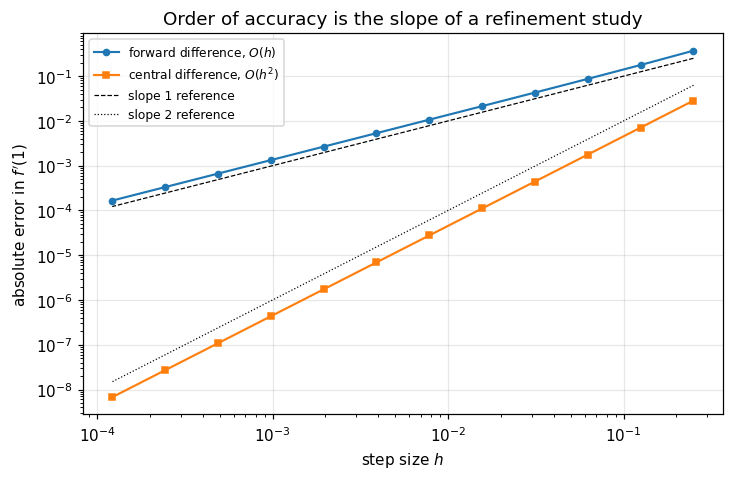

In [8]:
fig, ax = plt.subplots()
for order, name, marker in [(1, "forward difference, $O(h)$", "o"),
                            (2, "central difference, $O(h^2)$", "s")]:
    errs = np.array([fd_error(h, order) for h in hs])
    ax.loglog(hs, errs, marker + "-", ms=4, lw=1.4, label=name)

ax.loglog(hs, hs, "k--", lw=0.8, label="slope 1 reference")
ax.loglog(hs, hs**2, "k:", lw=0.8, label="slope 2 reference")
ax.set_xlabel("step size $h$")
ax.set_ylabel("absolute error in $f'(1)$")
ax.set_title("Order of accuracy is the slope of a refinement study")
ax.legend(fontsize=8)
plt.show()

**What to take from this.** Each curve runs parallel to its reference line. That parallelism
*is* the order claim, and it is how every order claim in Parts 9, 10 and 11 will be checked.
Notice we deliberately stopped at $h = 2^{-13}$: go smaller and we fall into the roundoff
branch of lesson 04's V, where the slope is meaningless.

## 7. Practical guidance

**How many steps will I need?**

For linear convergence with rate $C$, going from error $e_0$ to tolerance $\tau$ needs about

$$k \approx \frac{\log(\tau / e_0)}{\log C} \quad\text{steps.}$$

For quadratic convergence, the number of correct digits doubles each step, so from $d_0$
correct digits you need about $\log_2(16/d_0)$ steps to reach full double precision. Usually
three to five.

In [9]:
tau, e0 = 1e-12, 1.0
for C in [0.5, 0.9, 0.99]:
    k = np.log(tau / e0) / np.log(C)
    print(f"linear with C = {C:<5}: about {k:6.0f} steps to reach 1e-12")

print()
d0 = 1.0
k = 0
while d0 < 16:
    d0 *= 2
    k += 1
print(f"quadratic from 1 correct digit : {k} steps to reach 16 digits")
print("\nthat gap is why Newton is worth its extra cost per step whenever it applies.")

linear with C = 0.5  : about     40 steps to reach 1e-12
linear with C = 0.9  : about    262 steps to reach 1e-12
linear with C = 0.99 : about   2749 steps to reach 1e-12

quadratic from 1 correct digit : 4 steps to reach 16 digits

that gap is why Newton is worth its extra cost per step whenever it applies.


## 8. Complexity

Measuring a convergence order is cheap and you should always do it.

| Task | Cost |
|---|---|
| Observed order from $n$ errors | $O(n)$, a handful of logarithms |
| Refinement study over $m$ step sizes | $m$ runs of the method |
| Power law fit | $O(m)$, one least squares fit on 2 unknowns |

A refinement study is the single most valuable test you can write for a numerical method. It
catches an entire class of bug that unit tests on individual values miss: an implementation
that is *slightly* wrong often still converges, but at the wrong order. **A method claiming
second order that measures 1.0 has a bug**, even if every individual answer looks plausible.

## 9. Common mistakes

1. **Measuring the order after the error hits roundoff.** The estimates become noise. Truncate
   first.
2. **Measuring the order before the asymptotic regime starts.** The first few steps of Newton
   from a poor guess look nothing like quadratic.
3. **Using one pair of step sizes.** Fit across the whole range instead. One pair cannot tell
   you whether the behaviour is a power law at all.
4. **Confusing order of convergence with order of accuracy.** One is against step number, the
   other against step size. Both are called "order".
5. **Treating $O(h^2)$ as a promise of accuracy.** It says how the error *scales*, not how big
   it is. A second order method with a huge constant can be worse than a first order method
   with a small one, at the step sizes you can afford.
6. **Forgetting Taylor's theorem needs the derivatives to exist.** For a function with a kink,
   the remainder term does not apply and the order collapses.

## 10. Exercises

**Level 1, conceptual**

1.1 A method has linear convergence with $C = 0.5$. How many iterations to gain 10 decimal
digits? Now answer the same question for a quadratic method starting from 1 correct digit.

1.2 What is the difference between $O(h^2)$ and $o(h^2)$? Give a function that is one but not
the other.

1.3 Why does measuring an observed order become meaningless once the error reaches $10^{-16}$?

**Level 2, mathematical**

2.1 Use Taylor's theorem to derive the error term of the central difference formula
$\frac{f(x+h)-f(x-h)}{2h}$, and show it is $-\frac{h^2}{6}f'''(\xi)$.

2.2 Prove that Newton's method converges quadratically to a simple root, and identify the
asymptotic error constant as $|f''(r) / (2f'(r))|$. Verify it numerically for
$f(x) = x^2 - 2$.

2.3 Show that the secant method has order $p = (1+\sqrt5)/2$, by assuming
$e_{k+1} = Ce_k^p$ and using $e_{k+1} \approx K e_k e_{k-1}$.

2.4 Prove that Rolle's theorem applied $n$ times to $f - p_n$, where $p_n$ interpolates $f$ at
$n+1$ points, produces a point where the $n$-th derivative of the difference vanishes. This is
the key step in lesson 45.

**Level 3, computational**

3.1 Write your own `observed_order` and reproduce the table in section 5. Handle the
truncation at roundoff correctly.

3.2 Write a `refinement_study(method, hs, exact)` helper that runs a method at several step
sizes, fits the order, and warns if the fit is poor. Use it on the trapezoid rule from lesson
61 when you get there.

3.3 Implement the Taylor series for $\sin x$ and verify the Lagrange remainder bound at several
orders and several $x$, as section 2 did for $\exp$.

**Level 4, experimental**

4.1 Run Newton's method on $f(x) = x^2 - 2$ starting from $x_0 = 10^6$. Plot the error. How
many steps before quadratic convergence begins? What is happening before that?

4.2 Run Newton on $f(x) = (x-1)^3$, which has a triple root. Measure the observed order. Why is
it 1 rather than 2? Then apply the modified Newton step $x - 3f/f'$ and measure again.

4.3 Take the Taylor series for $e^{-10}$ and sum it directly. Measure the error against the
number of terms. Explain the result in terms of lesson 05 rather than lesson 07.

**Level 5, advanced**

5.1 Derive the order of convergence of the **Steffensen** iteration and confirm it numerically.
How does it achieve quadratic convergence without derivatives?

5.2 **Aitken extrapolation** turns a linearly convergent sequence into a faster one. Implement
it, apply it to the bisection and fixed point sequences from section 5, and measure the new
order.

5.3 A method whose error behaves like $E(h) = C_1h^2 + C_2h^3$ will measure an order slightly
above 2 at large $h$ and approach exactly 2 as $h \to 0$. Construct such a case, measure the
order at a range of $h$, and show how **Richardson extrapolation** (lesson 62) removes the
leading term and raises the observed order.

Solutions are in [`solutions/part01_foundations.md`](../solutions/part01_foundations.md).

## 11. Key takeaways

- **Taylor's theorem with remainder** is the source of nearly every truncation error estimate
  in this course. The remainder is exact, and it shows both the **order** and the dependence on
  a **high derivative**.
- **IVT** underwrites bisection, **Rolle** underwrites the interpolation error formula, **MVT**
  underwrites finite differences.
- **Order of convergence** $p$: the error satisfies $e_{k+1} \approx Ce_k^p$. Linear means a
  fixed number of digits per step, quadratic means the digits **double**.
- Measure $p$ from three consecutive errors. The estimate is only valid in the window between
  the start-up phase and the roundoff floor.
- **Order of accuracy** is different: it is $E(h) = O(h^p)$ as $h \to 0$, measured by a
  refinement study. Halving $h$ should divide the error by $2^p$.
- A refinement study is the best single test of a numerical implementation. Wrong order means
  a bug, even when individual answers look fine.
- Measured in this lesson: bisection $p = 1$, secant $p = 1.618$, Newton $p = 2$, forward
  difference order 1, central difference order 2, all within 0.05 of theory.

## Where this goes next

Lesson 08 does for **cost** what this lesson did for **accuracy**: makes the claims precise and
then measures them. After that Part 1 is complete, and Part 2 puts all six foundation lessons
to work on the first real problem, solving $f(x) = 0$.

---

*Sources: Sauer, Numerical Analysis 3rd ed., section 0.5 (review of calculus) and the
convergence analysis in sections 1.1 to 1.5; Gupta, Numerical Methods, Appendix C (Taylor
series) and sections 3.8 and 3.9 (convergence criteria and order of convergence for
root-finding methods). The numerical measurement of observed order, and the refinement study
methodology, are supplementary tooling built for this course.*